# 04 – Improved Model
Forbedret CNN med augmentation, residual connections, hyperparameter-tuning.

In [12]:
# ============================================================
# 04_improved_model.ipynb  –  Forbedret CNN med augmentation
# ============================================================

# --- 1. Importer og seed ---
import random
import numpy as np
import matplotlib.pyplot as plt
import pickle, json
from pathlib import Path
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [13]:
# --- 2. Monter Drive og stier ---
import os
from google.colab import drive

if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')

PROCESSED = Path("/content/drive/MyDrive/processed")
print("Filer:", [f.name for f in PROCESSED.iterdir()])

Filer: ['X_val.npy', 'y_train.npy', 'y_val.npy', 'y_test.npy', 'label_encoder.pkl', 'X_test.npy', 'X_train.npy', 'baseline_best.keras', 'baseline_training_curves.png', 'baseline_confusion_matrix.png', 'baseline_resultater.json', 'improved_best.keras']


In [14]:
# --- 3. Last inn data ---
X_train = np.load(PROCESSED / "X_train.npy")
y_train = np.load(PROCESSED / "y_train.npy")
X_val   = np.load(PROCESSED / "X_val.npy")
y_val   = np.load(PROCESSED / "y_val.npy")
X_test  = np.load(PROCESSED / "X_test.npy")
y_test  = np.load(PROCESSED / "y_test.npy")

with open(PROCESSED / "label_encoder.pkl", "rb") as f:
    le = pickle.load(f)

NUM_CLASSES = len(le.classes_)
INPUT_SHAPE = X_train.shape[1:]

print(f"X_train shape : {X_train.shape}")
print(f"Input shape   : {INPUT_SHAPE}")
print(f"Klasser ({NUM_CLASSES}): {list(le.classes_)}")

X_train shape : (4695, 128, 130, 1)
Input shape   : (128, 130, 1)
Klasser (11): [np.str_('cel'), np.str_('cla'), np.str_('flu'), np.str_('gac'), np.str_('gel'), np.str_('org'), np.str_('pia'), np.str_('sax'), np.str_('tru'), np.str_('vio'), np.str_('voi')]


In [15]:
# --- 4. Data augmentation ---
data_augmentation = keras.Sequential([
    layers.RandomTranslation(height_factor=0.0, width_factor=0.1),
], name="augmentation")

In [16]:
# --- 5. Residual blokk ---
def residual_block(x, filters):
    shortcut = x

    x = layers.Conv2D(filters, (3, 3), padding='same',
                      kernel_initializer='he_uniform')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(filters, (3, 3), padding='same',
                      kernel_initializer='he_uniform')(x)
    x = layers.BatchNormalization()(x)

    # Tilpass shortcut hvis antall filtre er forskjellig
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, (1, 1), padding='same',
                                 kernel_initializer='he_uniform')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x

In [17]:
# --- 6. Bygg forbedret modell ---
def build_improved_model(input_shape, num_classes):
    inputs = keras.Input(shape=input_shape)

    # Augmentation kun under trening
    x = data_augmentation(inputs)

    # Inngangsblokk
    x = layers.Conv2D(32, (3, 3), padding='same',
                      kernel_initializer='he_uniform')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Residual blokker med økende filtre
    x = residual_block(x, 64)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.2)(x)

    x = residual_block(x, 128)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.2)(x)

    x = residual_block(x, 256)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.3)(x)

    x = residual_block(x, 256)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return keras.Model(inputs, outputs, name="improved_cnn")

model = build_improved_model(INPUT_SHAPE, NUM_CLASSES)
model.summary()

Model: "improved_cnn"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128, 130,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augmentation        │ (None, 128, 130,  │          0 │ input_layer_2[0]… │
│ (Sequential)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 128, 130,  │        320 │ augmentation[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 130,  │        128 │ conv2d_12[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_9        │ (None, 128, 130,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 64, 65,    │          0 │ activation_9[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 64, 65,    │     18,496 │ max_pooling2d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 65,    │        256 │ conv2d_13[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_10       │ (None, 64, 65,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 64, 65,    │     36,928 │ activation_10[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 64, 65,    │      2,112 │ max_pooling2d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 65,    │        256 │ conv2d_14[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 65,    │        256 │ conv2d_15[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 64, 65,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_11       │ (None, 64, 65,    │          0 │ add_4[0][0]       │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 32, 32,    │          0 │ activation_11[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 32, 32,    │          0 │ max_pooling2d_5[

 Total params: 2,396,427 (9.14 MB)

 Trainable params: 2,392,651 (9.13 MB)

 Non-trainable params: 3,776 (14.75 KB)

In [18]:
# --- 7. Kompiler ---
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [19]:
# --- 8. Callbacks ---
CHECKPOINT_PATH = str(PROCESSED / "improved_best.keras")

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=12,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        CHECKPOINT_PATH,
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

In [20]:
# --- 9. Tren modellen ---
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.1898 - loss: 2.9251
Epoch 1: val_loss improved from None to 2.60287, saving model to /content/drive/MyDrive/processed/improved_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/processed/improved_best.keras
147/147 ━━━━━━━━━━━━━━━━━━━━ 26s 119ms/step - accuracy: 0.2547 - loss: 2.4469 - val_accuracy: 0.2400 - val_loss: 2.6029 - learning_rate: 0.0010
Epoch 2/100
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.3752 - loss: 1.8797
Epoch 2: val_loss did not improve from 2.60287
147/147 ━━━━━━━━━━━━━━━━━━━━ 16s 112ms/step - accuracy: 0.4092 - loss: 1.7796 - val_accuracy: 0.2291 - val_loss: 2.9659 - learning_rate: 0.0010
Epoch 3/100
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.4810 - loss: 1.5942
Epoch 3: val_loss did not improve from 2.60287
147/147 ━━━━━━━━━━━━━━━━━━━━ 16s 109ms/step - accuracy: 0.5050 - loss: 1.5092 - val_accuracy: 0.2590 - val_loss: 2.9467 - learning_rate: 0.0010
E

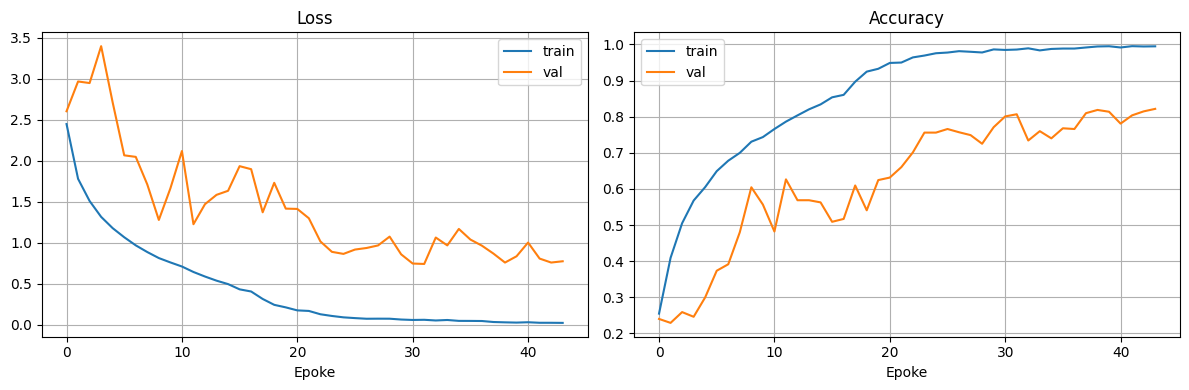

In [21]:
# --- 10. Treningskurver ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['loss'],     label='train')
ax1.plot(history.history['val_loss'], label='val')
ax1.set_title('Loss'); ax1.set_xlabel('Epoke')
ax1.legend(); ax1.grid(True)

ax2.plot(history.history['accuracy'],     label='train')
ax2.plot(history.history['val_accuracy'], label='val')
ax2.set_title('Accuracy'); ax2.set_xlabel('Epoke')
ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.savefig(PROCESSED / "improved_training_curves.png", dpi=150)
plt.show()

In [22]:
# --- 11. Evaluer på testsettet ---
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest loss    : {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")


Test loss    : 0.8208
Test accuracy: 0.7913


In [23]:
# --- 12. Classification report ---
y_pred = np.argmax(model.predict(X_test), axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step

Classification Report:
              precision    recall  f1-score   support

         cel       0.59      0.88      0.71        58
         cla       0.82      0.62      0.71        76
         flu       0.75      0.84      0.79        68
         gac       0.78      0.83      0.81        96
         gel       0.83      0.70      0.76       114
         org       0.90      0.89      0.90       102
         pia       0.78      0.96      0.86       108
         sax       0.71      0.56      0.63        94
         tru       0.73      0.88      0.80        86
         vio       0.77      0.61      0.68        87
         voi       0.97      0.89      0.93       117

    accuracy                           0.79      1006
   macro avg       0.79      0.79      0.78      1006
weighted avg       0.80      0.79      0.79      1006



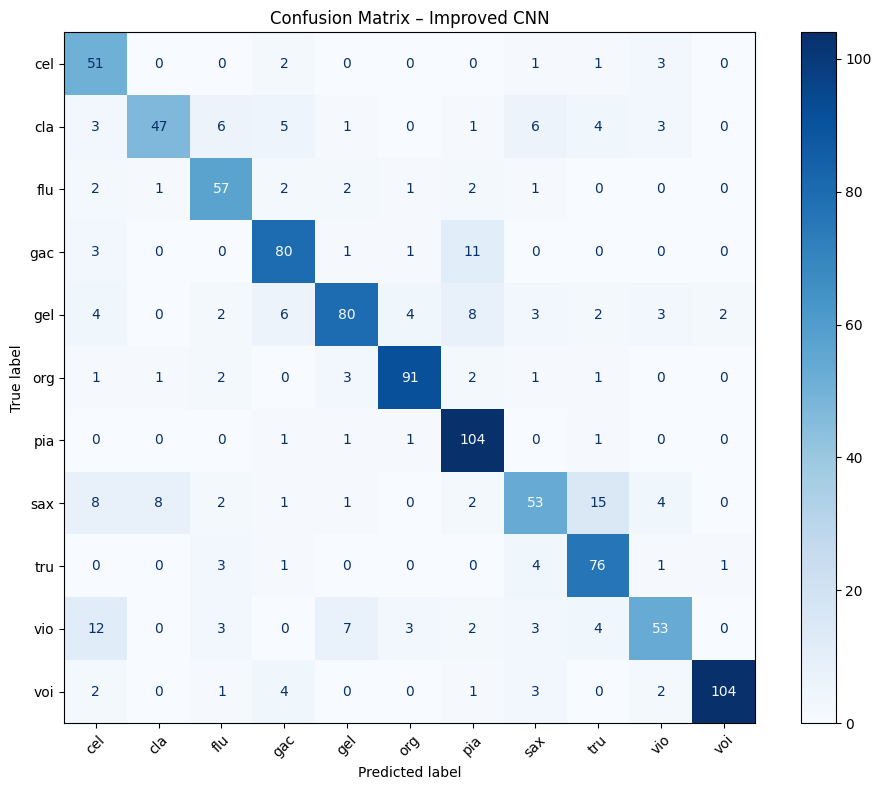

In [24]:
# --- 13. Confusion matrix ---
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=le.classes_,
    xticks_rotation=45,
    cmap='Blues',
    ax=ax
)
plt.title("Confusion Matrix – Improved CNN")
plt.tight_layout()
plt.savefig(PROCESSED / "improved_confusion_matrix.png", dpi=150)
plt.show()

In [25]:
# --- 14. Sammenlign med baseline ---
baseline = json.load(open(PROCESSED / "baseline_resultater.json"))

print(f"\n{'Modell':<20} {'Test Acc':>10}")
print("-" * 32)
print(f"{'Dummy':<20} {baseline['dummy_accuracy']:>10.4f}")
print(f"{'Baseline CNN':<20} {baseline['test_accuracy']:>10.4f}")
print(f"{'Improved CNN':<20} {test_acc:>10.4f}")


Modell                 Test Acc
--------------------------------
Dummy                    0.1163
Baseline CNN             0.7286
Improved CNN             0.7913


In [26]:
# --- 15. Lagre resultater ---
resultater = {
    "test_loss":     float(test_loss),
    "test_accuracy": float(test_acc),
    "epoker_trent":  len(history.history['loss']),
    "klasser":       list(le.classes_)
}

with open(PROCESSED / "improved_resultater.json", "w") as f:
    json.dump(resultater, f, indent=2)

print("Resultater lagret!")
print(json.dumps(resultater, indent=2))

Resultater lagret!
{
  "test_loss": 0.8207841515541077,
  "test_accuracy": 0.7912524938583374,
  "epoker_trent": 44,
  "klasser": [
    "cel",
    "cla",
    "flu",
    "gac",
    "gel",
    "org",
    "pia",
    "sax",
    "tru",
    "vio",
    "voi"
  ]
}
